# Revision: 6-31G(d) vs 6-31+G(d) TS bond lengths

This notebook prepares the basis-set sensitivity calculation requested during revision and analyzes the resulting transition-state geometries. It uses the 15 benchmark TS structures in `Benchmark_new/OPT`, changes **only** `6-31G(d)` to `6-31+G(d)`, and compares the forming B–Cl and breaking C–Cl distances.

Success criteria:

- one validated `6-31+G(d)` Gaussian input per benchmark TS;
- normal termination and exactly one imaginary frequency for every new TS;
- signed and absolute B–Cl/C–Cl distance changes exported as a reviewer-ready table and figure.


## 1. Setup and paths

Raw Gaussian files remain in the external benchmark workspace. Tables and figures are written to the repository's `output/revision_basis_set_geometry` folder. Override `BORYLXAT_RAW_CALC_ROOT` before running if the raw calculation root is elsewhere.


In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from DFTStructureGenerator.FormatConverter import read_gjf
from DFTStructureGenerator.logfile_process import Logfile
from DFTStructureGenerator.project_paths import raw_calc_path

BENCHMARK_DIR = raw_calc_path("Benchmark_new")
SOURCE_DIR = BENCHMARK_DIR / "OPT"
PLUS_BASIS_DIR = BENCHMARK_DIR / "OPT_6-31plusGd"
RESULT_DIR = Path("output") / "revision_basis_set_geometry"

NPROC_SHARED = 32
MEMORY = "100GB"
OVERWRITE_INPUTS = True
EXPECTED_REACTIVE_SYMBOLS = ["B", "Cl", "C"]

if not SOURCE_DIR.is_dir():
    raise FileNotFoundError(f"Benchmark OPT directory not found: {SOURCE_DIR}")
PLUS_BASIS_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print(f"6-31G(d) source: {SOURCE_DIR}")
print(f"6-31+G(d) jobs:  {PLUS_BASIS_DIR}")
print(f"Analysis output: {RESULT_DIR.resolve()}")


6-31G(d) source: E:\work\B_Cl_Nu\Benchmark_new\OPT
6-31+G(d) jobs:  E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd
Analysis output: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\revision_basis_set_geometry


## 2. Read and validate the 6-31G(d) benchmark TS structures

The Gaussian title stores the reactive B–Cl–C atom numbers (1-based). The explicit symbol check below prevents accidental measurement of a spectator chlorine or an unrelated carbon. Final optimized coordinates are taken from the last geometry in each normally terminated log.


In [2]:
def distance(positions, atom_i, atom_j):
    return float(np.linalg.norm(positions[atom_i] - positions[atom_j]))


def load_ts_record(log_path):
    parsed = Logfile(
        str(log_path),
        read_title=True,
        freq_warning=True,
        ignore_print=True,
    )
    if not parsed.normal_end:
        raise ValueError(f"Not normally terminated: {log_path.name}")
    if parsed.running_positions is None or len(parsed.running_positions) == 0:
        raise ValueError(f"No optimized coordinates: {log_path.name}")
    if not isinstance(parsed.title, list) or len(parsed.title) < 3:
        raise ValueError(f"Reactive atom indices missing from title: {log_path.name}")

    reactive_indices = [int(value) - 1 for value in parsed.title[:3]]
    reactive_symbols = [parsed.symbol_list[index] for index in reactive_indices]
    if reactive_symbols != EXPECTED_REACTIVE_SYMBOLS:
        raise ValueError(
            f"Expected B-Cl-C at {parsed.title[:3]} in {log_path.name}; "
            f"found {reactive_symbols}"
        )

    positions = np.asarray(parsed.running_positions[-1], dtype=float)
    b_idx, cl_idx, c_idx = reactive_indices
    return {
        "name": log_path.stem,
        "source_log": log_path,
        "parsed": parsed,
        "symbols": list(parsed.symbol_list),
        "positions_631gd": positions,
        "reactive_indices": reactive_indices,
        "B_atom_1based": b_idx + 1,
        "Cl_atom_1based": cl_idx + 1,
        "C_atom_1based": c_idx + 1,
        "charge": parsed.charge,
        "multiplicity": parsed.multiplicity,
        "imaginary_frequency_count_631gd": parsed.unreal_freq,
        "route_631gd": parsed.method,
        "B_Cl_631gd_A": distance(positions, b_idx, cl_idx),
        "C_Cl_631gd_A": distance(positions, c_idx, cl_idx),
    }


source_logs = sorted(SOURCE_DIR.glob("B_*_L_*_Cl_*.log"))
source_records = [load_ts_record(path) for path in source_logs]
if not source_records:
    raise RuntimeError(f"No benchmark TS logs found in {SOURCE_DIR}")

baseline_columns = [
    "name", "B_atom_1based", "Cl_atom_1based", "C_atom_1based",
    "charge", "multiplicity", "imaginary_frequency_count_631gd",
    "B_Cl_631gd_A", "C_Cl_631gd_A", "route_631gd",
]
baseline_df = pd.DataFrame(
    [{column: record[column] for column in baseline_columns} for record in source_records]
)
baseline_df.to_csv(RESULT_DIR / "baseline_631gd_bond_lengths.csv", index=False)

print(f"Validated {len(source_records)} benchmark transition states.")
display(baseline_df)


Validated 15 benchmark transition states.


,name,B_atom_1based,Cl_atom_1based,C_atom_1based,charge,multiplicity,imaginary_frequency_count_631gd,B_Cl_631gd_A,C_Cl_631gd_A,route_631gd
0,B_00388_L_00001_Cl_00475,1,2,19,0,2,1,2.588579,1.931784,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
1,B_00388_L_00001_Cl_00477,1,2,18,0,2,1,2.593617,1.901643,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
2,B_00388_L_00001_Cl_00490,1,2,19,0,2,1,2.607303,1.878886,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
3,B_00388_L_00001_Cl_00506,1,2,19,0,2,1,2.842014,1.969860,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
4,B_00388_L_00001_Cl_00519,1,2,18,0,2,1,2.761061,1.948254,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
5,B_00388_L_00069_Cl_00490,1,2,19,0,2,1,2.403261,1.981529,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
6,B_00388_L_00072_Cl_00490,1,2,37,0,2,1,2.412665,1.973693,"opt=(calcfc,ts,noeigen,maxcycles=100) freq b3l..."
7,B_00388_L_00072_Cl_00519,1,2,36,0,2,1,2.518103,2.050808,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
8,B_00391_L_00033_Cl_00477,1,4,27,0,2,1,2.411831,2.003671,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
9,B_00391_L_00033_Cl_00519,1,4,27,0,2,1,2.571729,2.063907,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."


## 3. Generate 6-31+G(d) Gaussian inputs

The original route is reused verbatim except for the basis-set substitution. This preserves each structure's original `maxcycles` value and all other model chemistry. Gaussian will use the open-shell form for these neutral doublets; the charge and multiplicity are copied directly from the source log.


In [3]:
def plus_basis_route(original_route):
    updated_route, count = re.subn(
        r"/6-31g\(d\)",
        "/6-31+G(d)",
        original_route,
        count=1,
        flags=re.IGNORECASE,
    )
    if count != 1:
        raise ValueError(f"Expected one 6-31G(d) basis token, found {count}: {original_route}")
    return updated_route


def write_gaussian_input(record, target_path):
    title = " ".join(str(index + 1) for index in record["reactive_indices"])
    route = plus_basis_route(record["route_631gd"])
    lines = [
        f"%nprocshared={NPROC_SHARED}",
        f"%mem={MEMORY}",
        f"#p {route}",
        "",
        f"$$$${title}####{record['charge']}????",
        "",
        f"{record['charge']} {record['multiplicity']}",
    ]
    for symbol, xyz in zip(record["symbols"], record["positions_631gd"]):
        lines.append(f" {symbol:<2s} {xyz[0]: .8f} {xyz[1]: .8f} {xyz[2]: .8f}")
    lines.extend(["", ""])
    target_path.write_text("\n".join(lines), encoding="utf-8")
    return route


generated_rows = []
for record in source_records:
    target_path = PLUS_BASIS_DIR / f"{record['name']}.gjf"
    if OVERWRITE_INPUTS or not target_path.exists():
        route = write_gaussian_input(record, target_path)
        action = "written"
    else:
        route = plus_basis_route(record["route_631gd"])
        action = "kept_existing"
    generated_rows.append({
        "name": record["name"],
        "input_file": str(target_path),
        "action": action,
        "route_631plusgd": route,
    })

input_manifest_df = pd.DataFrame(generated_rows)
input_manifest_df.to_csv(RESULT_DIR / "631plusgd_input_manifest.csv", index=False)
print(input_manifest_df["action"].value_counts().to_string())
display(input_manifest_df)


action
written    15


,name,input_file,action,route_631plusgd
0,B_00388_L_00001_Cl_00475,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
1,B_00388_L_00001_Cl_00477,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
2,B_00388_L_00001_Cl_00490,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
3,B_00388_L_00001_Cl_00506,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
4,B_00388_L_00001_Cl_00519,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
5,B_00388_L_00069_Cl_00490,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
6,B_00388_L_00072_Cl_00490,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=100) freq b3l..."
7,B_00388_L_00072_Cl_00519,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
8,B_00391_L_00033_Cl_00477,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."
9,B_00391_L_00033_Cl_00519,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,written,"opt=(calcfc,ts,noeigen,maxcycles=64) freq b3ly..."


In [4]:
# Independent read-back: route, atom order, coordinates, charge, and multiplicity.
verification_rows = []
for record in source_records:
    input_path = PLUS_BASIS_DIR / f"{record['name']}.gjf"
    atoms, positions, method, charge, multiplicity, title = read_gjf(
        str(input_path), read_details=True
    )
    positions = np.asarray(positions, dtype=float)
    checks = {
        "basis_is_631plusgd": bool(re.search(r"/6-31\+g\(d\)", method, re.IGNORECASE)),
        "atom_order_matches": atoms == record["symbols"],
        "coordinates_match": bool(np.allclose(positions, record["positions_631gd"], atol=1e-7)),
        "charge_matches": charge == record["charge"],
        "multiplicity_matches": multiplicity == record["multiplicity"],
    }
    verification_rows.append({"name": record["name"], **checks, "all_checks_pass": all(checks.values())})

verification_df = pd.DataFrame(verification_rows)
verification_df.to_csv(RESULT_DIR / "631plusgd_input_verification.csv", index=False)
assert verification_df["all_checks_pass"].all(), "At least one generated input failed read-back validation."
print(f"All {len(verification_df)} generated inputs passed read-back validation.")
display(verification_df)


All 15 generated inputs passed read-back validation.


,name,basis_is_631plusgd,atom_order_matches,coordinates_match,charge_matches,multiplicity_matches,all_checks_pass
0,B_00388_L_00001_Cl_00475,True,True,True,True,True,True
1,B_00388_L_00001_Cl_00477,True,True,True,True,True,True
2,B_00388_L_00001_Cl_00490,True,True,True,True,True,True
3,B_00388_L_00001_Cl_00506,True,True,True,True,True,True
4,B_00388_L_00001_Cl_00519,True,True,True,True,True,True
5,B_00388_L_00069_Cl_00490,True,True,True,True,True,True
6,B_00388_L_00072_Cl_00490,True,True,True,True,True,True
7,B_00388_L_00072_Cl_00519,True,True,True,True,True,True
8,B_00391_L_00033_Cl_00477,True,True,True,True,True,True
9,B_00391_L_00033_Cl_00519,True,True,True,True,True,True


## 4. Run Gaussian, then collect the new geometries

Submit the `.gjf` files in `OPT_6-31plusGd` and place each Gaussian output beside its input as `<same_stem>.log` (a same-stem `.out` is also accepted). Re-run this section after the jobs finish. A geometry is included in the comparison only when Gaussian terminates normally and the frequency calculation reports exactly one imaginary frequency.


In [3]:
comparison_columns = [
    "name", "B_atom_1based", "Cl_atom_1based", "C_atom_1based",
    "B_Cl_631gd_A", "B_Cl_631plusgd_A", "delta_B_Cl_A", "abs_delta_B_Cl_A",
    "C_Cl_631gd_A", "C_Cl_631plusgd_A", "delta_C_Cl_A", "abs_delta_C_Cl_A",
]
qc_rows = []
comparison_rows = []

for record in source_records:
    candidates = [
        PLUS_BASIS_DIR / f"{record['name']}.log",
        PLUS_BASIS_DIR / f"{record['name']}.out",
    ]
    output_path = next((path for path in candidates if path.exists()), None)
    if output_path is None:
        qc_rows.append({"name": record["name"], "status": "missing_output", "output_file": None})
        continue

    try:
        parsed = Logfile(
            str(output_path), read_title=True, freq_warning=True, ignore_print=True
        )
        normal_end = bool(parsed.normal_end)
        imaginary_count = parsed.unreal_freq if normal_end else -1
        atom_order_matches = list(parsed.symbol_list or []) == record["symbols"]
        has_geometry = parsed.running_positions is not None and len(parsed.running_positions) > 0
        status = "ready"
        if not normal_end:
            status = "not_normal_termination"
        elif imaginary_count != 1:
            status = "wrong_imaginary_frequency_count"
        elif not atom_order_matches:
            status = "atom_order_mismatch"
        elif not has_geometry:
            status = "missing_geometry"

        qc_rows.append({
            "name": record["name"],
            "status": status,
            "output_file": str(output_path),
            "normal_termination": normal_end,
            "imaginary_frequency_count": imaginary_count,
            "atom_order_matches": atom_order_matches,
        })
        if status != "ready":
            continue

        plus_positions = np.asarray(parsed.running_positions[-1], dtype=float)
        b_idx, cl_idx, c_idx = record["reactive_indices"]
        b_cl_plus = distance(plus_positions, b_idx, cl_idx)
        c_cl_plus = distance(plus_positions, c_idx, cl_idx)
        delta_b_cl = b_cl_plus - record["B_Cl_631gd_A"]
        delta_c_cl = c_cl_plus - record["C_Cl_631gd_A"]
        comparison_rows.append({
            "name": record["name"],
            "B_atom_1based": b_idx + 1,
            "Cl_atom_1based": cl_idx + 1,
            "C_atom_1based": c_idx + 1,
            "B_Cl_631gd_A": record["B_Cl_631gd_A"],
            "B_Cl_631plusgd_A": b_cl_plus,
            "delta_B_Cl_A": delta_b_cl,
            "abs_delta_B_Cl_A": abs(delta_b_cl),
            "C_Cl_631gd_A": record["C_Cl_631gd_A"],
            "C_Cl_631plusgd_A": c_cl_plus,
            "delta_C_Cl_A": delta_c_cl,
            "abs_delta_C_Cl_A": abs(delta_c_cl),
        })
    except Exception as exc:
        qc_rows.append({
            "name": record["name"],
            "status": "parse_error",
            "output_file": str(output_path),
            "error": repr(exc),
        })

qc_columns = [
    "name", "status", "output_file", "normal_termination",
    "imaginary_frequency_count", "atom_order_matches", "error",
]
qc_df = pd.DataFrame(qc_rows).reindex(columns=qc_columns)
comparison_df = pd.DataFrame(comparison_rows, columns=comparison_columns)
qc_df.to_csv(RESULT_DIR / "631plusgd_output_qc.csv", index=False)
comparison_df.to_csv(RESULT_DIR / "basis_set_bond_length_comparison.csv", index=False)

print(f"Comparison-ready outputs: {len(comparison_df)}/{len(source_records)}")
display(qc_df)
if not comparison_df.empty:
    display(comparison_df)


Comparison-ready outputs: 14/15


,name,status,output_file,normal_termination,imaginary_frequency_count,atom_order_matches,error
0,B_00388_L_00001_Cl_00475,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
1,B_00388_L_00001_Cl_00477,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
2,B_00388_L_00001_Cl_00490,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
3,B_00388_L_00001_Cl_00506,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
4,B_00388_L_00001_Cl_00519,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
5,B_00388_L_00069_Cl_00490,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
6,B_00388_L_00072_Cl_00490,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
7,B_00388_L_00072_Cl_00519,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
8,B_00391_L_00033_Cl_00477,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN
9,B_00391_L_00033_Cl_00519,ready,E:\work\B_Cl_Nu\Benchmark_new\OPT_6-31plusGd\B...,True,1,True,NaN


,name,B_atom_1based,Cl_atom_1based,C_atom_1based,B_Cl_631gd_A,B_Cl_631plusgd_A,delta_B_Cl_A,abs_delta_B_Cl_A,C_Cl_631gd_A,C_Cl_631plusgd_A,delta_C_Cl_A,abs_delta_C_Cl_A
0,B_00388_L_00001_Cl_00475,1,2,19,2.588579,2.593978,0.005399,0.005399,1.931784,1.937904,0.006120,0.006120
1,B_00388_L_00001_Cl_00477,1,2,18,2.593617,2.590244,-0.003374,0.003374,1.901643,1.908788,0.007145,0.007145
2,B_00388_L_00001_Cl_00490,1,2,19,2.607303,2.624819,0.017516,0.017516,1.878886,1.869794,-0.009092,0.009092
3,B_00388_L_00001_Cl_00506,1,2,19,2.842014,2.823725,-0.018288,0.018288,1.969860,1.986048,0.016188,0.016188
4,B_00388_L_00001_Cl_00519,1,2,18,2.761061,2.743411,-0.017650,0.017650,1.948254,1.964079,0.015826,0.015826
5,B_00388_L_00069_Cl_00490,1,2,19,2.403261,2.412359,0.009098,0.009098,1.981529,1.973238,-0.008291,0.008291
6,B_00388_L_00072_Cl_00490,1,2,37,2.412665,2.422889,0.010224,0.010224,1.973693,1.970142,-0.003551,0.003551
7,B_00388_L_00072_Cl_00519,1,2,36,2.518103,2.524021,0.005918,0.005918,2.050808,2.059001,0.008193,0.008193
8,B_00391_L_00033_Cl_00477,1,4,27,2.411831,2.404581,-0.007249,0.007249,2.003671,2.010579,0.006909,0.006909
9,B_00391_L_00033_Cl_00519,1,4,27,2.571729,2.562976,-0.008752,0.008752,2.063907,2.077563,0.013656,0.013656


## 5. Summarize B–Cl and C–Cl changes

Here, `delta = r[6-31+G(d)] - r[6-31G(d)]`; positive values indicate bond elongation with the diffuse-function basis. Partial results are labeled explicitly until all 15 jobs pass QC.


In [4]:
summary_columns = [
    "bond", "n", "mean_signed_delta_A", "mean_absolute_delta_A",
    "rms_delta_A", "median_signed_delta_A", "max_absolute_delta_A",
    "max_change_system", "max_change_signed_delta_A",
]
summary_rows = []
for bond_label, delta_column in [("B-Cl", "delta_B_Cl_A"), ("C-Cl", "delta_C_Cl_A")]:
    if comparison_df.empty:
        continue
    values = comparison_df[delta_column]
    max_index = values.abs().idxmax()
    summary_rows.append({
        "bond": bond_label,
        "n": len(values),
        "mean_signed_delta_A": values.mean(),
        "mean_absolute_delta_A": values.abs().mean(),
        "rms_delta_A": float(np.sqrt(np.mean(np.square(values)))),
        "median_signed_delta_A": values.median(),
        "max_absolute_delta_A": values.abs().max(),
        "max_change_system": comparison_df.loc[max_index, "name"],
        "max_change_signed_delta_A": values.loc[max_index],
    })

summary_df = pd.DataFrame(summary_rows, columns=summary_columns)
summary_df.to_csv(RESULT_DIR / "basis_set_bond_length_summary.csv", index=False)

if comparison_df.empty:
    print("No completed 6-31+G(d) outputs yet; inputs are ready, but bond-length changes cannot be evaluated.")
else:
    qualifier = "COMPLETE" if len(comparison_df) == len(source_records) else "PARTIAL"
    print(f"{qualifier} analysis: {len(comparison_df)}/{len(source_records)} TS structures passed QC.")
    display(summary_df)
    display(comparison_df.sort_values("abs_delta_B_Cl_A", ascending=False))


PARTIAL analysis: 14/15 TS structures passed QC.


,bond,n,mean_signed_delta_A,mean_absolute_delta_A,rms_delta_A,median_signed_delta_A,max_absolute_delta_A,max_change_system,max_change_signed_delta_A
0,B-Cl,14,-0.001545,0.008957,0.010440,-0.001579,0.018288,B_00388_L_00001_Cl_00506,-0.018288
1,C-Cl,14,0.007202,0.010192,0.011007,0.007669,0.016925,B_00394_L_00046_Cl_00519,0.016925


,name,B_atom_1based,Cl_atom_1based,C_atom_1based,B_Cl_631gd_A,B_Cl_631plusgd_A,delta_B_Cl_A,abs_delta_B_Cl_A,C_Cl_631gd_A,C_Cl_631plusgd_A,delta_C_Cl_A,abs_delta_C_Cl_A
3,B_00388_L_00001_Cl_00506,1,2,19,2.842014,2.823725,-0.018288,0.018288,1.969860,1.986048,0.016188,0.016188
4,B_00388_L_00001_Cl_00519,1,2,18,2.761061,2.743411,-0.017650,0.017650,1.948254,1.964079,0.015826,0.015826
2,B_00388_L_00001_Cl_00490,1,2,19,2.607303,2.624819,0.017516,0.017516,1.878886,1.869794,-0.009092,0.009092
11,B_00394_L_00046_Cl_00519,1,8,28,2.550640,2.540304,-0.010335,0.010335,2.036652,2.053578,0.016925,0.016925
6,B_00388_L_00072_Cl_00490,1,2,37,2.412665,2.422889,0.010224,0.010224,1.973693,1.970142,-0.003551,0.003551
5,B_00388_L_00069_Cl_00490,1,2,19,2.403261,2.412359,0.009098,0.009098,1.981529,1.973238,-0.008291,0.008291
9,B_00391_L_00033_Cl_00519,1,4,27,2.571729,2.562976,-0.008752,0.008752,2.063907,2.077563,0.013656,0.013656
12,B_00427_L_00046_Cl_00519,1,5,25,2.576298,2.568434,-0.007864,0.007864,2.051935,2.066089,0.014154,0.014154
8,B_00391_L_00033_Cl_00477,1,4,27,2.411831,2.404581,-0.007249,0.007249,2.003671,2.010579,0.006909,0.006909
7,B_00388_L_00072_Cl_00519,1,2,36,2.518103,2.524021,0.005918,0.005918,2.050808,2.059001,0.008193,0.008193


Saved: output\revision_basis_set_geometry\basis_set_bond_length_comparison.png


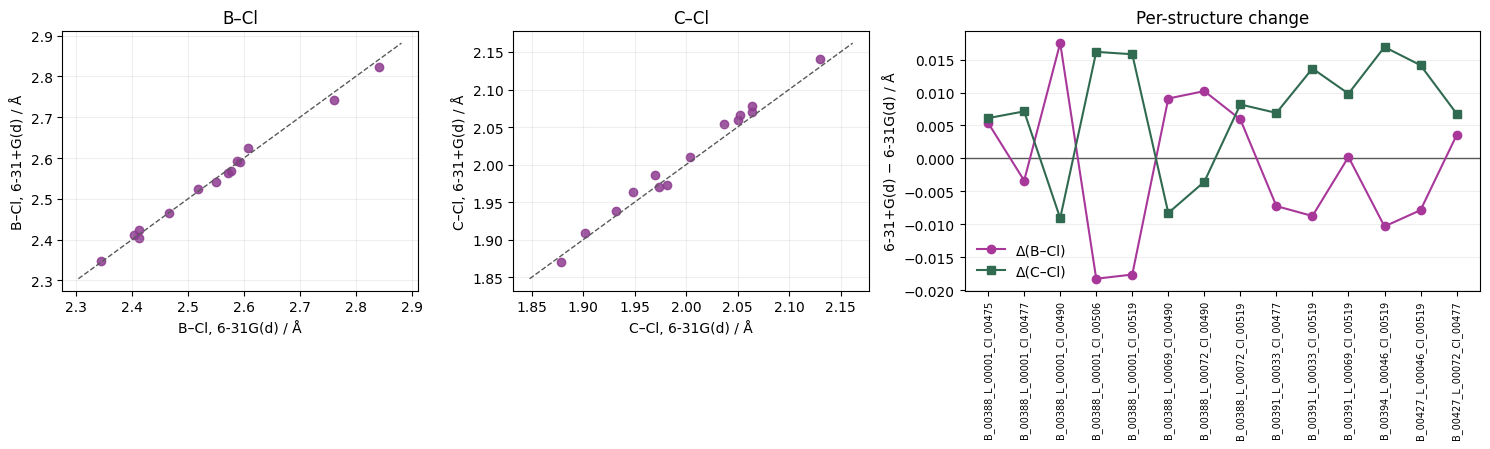

In [5]:
if comparison_df.empty:
    print("Figure deferred until at least one 6-31+G(d) output passes QC.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), gridspec_kw={"width_ratios": [1, 1, 1.45]})
    plot_specs = [
        (axes[0], "B_Cl_631gd_A", "B_Cl_631plusgd_A", "B–Cl"),
        (axes[1], "C_Cl_631gd_A", "C_Cl_631plusgd_A", "C–Cl"),
    ]
    for axis, x_column, y_column, label in plot_specs:
        axis.scatter(comparison_df[x_column], comparison_df[y_column], color="#8d3c8f", alpha=0.85)
        lower = min(comparison_df[x_column].min(), comparison_df[y_column].min())
        upper = max(comparison_df[x_column].max(), comparison_df[y_column].max())
        padding = max((upper - lower) * 0.08, 0.005)
        axis.plot([lower - padding, upper + padding], [lower - padding, upper + padding], "--", color="0.35", lw=1)
        axis.set_xlabel(f"{label}, 6-31G(d) / Å")
        axis.set_ylabel(f"{label}, 6-31+G(d) / Å")
        axis.set_title(label)
        axis.grid(alpha=0.2)

    order = np.arange(len(comparison_df))
    axes[2].axhline(0, color="0.35", lw=1)
    axes[2].plot(order, comparison_df["delta_B_Cl_A"], "o-", label="Δ(B–Cl)", color="#a8379a")
    axes[2].plot(order, comparison_df["delta_C_Cl_A"], "s-", label="Δ(C–Cl)", color="#306a51")
    axes[2].set_xticks(order)
    axes[2].set_xticklabels(comparison_df["name"], rotation=90, fontsize=7)
    axes[2].set_ylabel("6-31+G(d) − 6-31G(d) / Å")
    axes[2].set_title("Per-structure change")
    axes[2].legend(frameon=False)
    axes[2].grid(axis="y", alpha=0.2)

    fig.tight_layout()
    figure_path = RESULT_DIR / "basis_set_bond_length_comparison.png"
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {figure_path}")
    plt.show()


## 6. Revision handoff

After all 15 calculations pass QC, report the mean signed change, mean absolute change, RMS change, and largest absolute change for both bonds from `basis_set_bond_length_summary.csv`. The full per-structure table provides traceability for the reviewer response. Any output with zero or multiple imaginary frequencies must be reoptimized or inspected before it is included.
